In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import xgboost as xgb
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc

In [2]:
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

In [3]:
df = pd.read_csv("diabetes_dataset.csv")

## Potential Analyses

### 1. Descriptive Statistics
Summarize the dataset to understand the **central tendencies** (mean, median) and **dispersion** (variance, standard deviation) of the features.

### 2. Correlation Analysis
Examine relationships between variables to identify **strong associations** and potential **predictors of diabetes**.

### 3. Classification Models
Apply machine learning algorithms to classify individuals as:
- **Diabetic**
- **Non-diabetic**

Example approaches may include:

- Decision Trees
- Random Forest
- Naive bayes

### 4. Trend Analysis
Analyze temporal trends (2015–2022) to assess how **diabetes prevalence has evolved over time** and identify potential patterns or shifts.


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  object 
 2   age                   100000 non-null  float64
 3   location              100000 non-null  object 
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  object 
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   100000 non-null  int64  
 15  d

In [5]:
df.head(5)

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


In [6]:
df["smoking_history"].value_counts()

smoking_history
No Info        35816
never          35095
former          9352
current         9286
not current     6447
ever            4004
Name: count, dtype: int64

In [7]:
df.isnull().sum()

year                    0
gender                  0
age                     0
location                0
race:AfricanAmerican    0
race:Asian              0
race:Caucasian          0
race:Hispanic           0
race:Other              0
hypertension            0
heart_disease           0
smoking_history         0
bmi                     0
hbA1c_level             0
blood_glucose_level     0
diabetes                0
dtype: int64

In [8]:
d = df.copy()

In [9]:
d.shape

(100000, 16)

In [10]:
n_records = d.shape[0]
diabitic = d["diabetes"].value_counts()[1]
non_diabitic = d["diabetes"].value_counts()[0]
print("Total number of records: {}".format(n_records))
print("Individuals which are diabitic: {}".format(diabitic))
print("Individuals which are not diabitic: {}".format(non_diabitic))

Total number of records: 100000
Individuals which are diabitic: 8500
Individuals which are not diabitic: 91500


In [11]:
d.describe()

,year,age,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,bmi,hbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2018.360820,41.885856,0.202230,0.200150,0.198760,0.19888,0.199980,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,1.345239,22.516840,0.401665,0.400114,0.399069,0.39916,0.399987,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,2015.000000,0.080000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,2019.000000,24.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,2019.000000,43.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,2019.000000,60.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,2022.000000,80.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [12]:
d["age"].value_counts()

age
80.00    5621
51.00    1619
47.00    1574
48.00    1568
53.00    1542
         ... 
0.48       83
1.00       83
0.40       66
0.16       59
0.08       36
Name: count, Length: 102, dtype: int64

## Dataset Overview

- **Time Period:** 2015–2022  
- **Total Records:** 100,000  
- **Features:** 12 input columns + 1 target column  
- **Target Variable:** `diabetes`  

---

## Categorical Features

### Race
All race features are binary (0/1), so **no additional encoding is required**.

| Race Category        | Mean |
|----------------------|------|
| African American     | 0.202 |
| Asian                | 0.200 |
| Caucasian            | 0.199 |
| Hispanic             | 0.199 |
| Other                | 0.200 |

---

## Numerical Features

All numerical features are **continuous**.

| Feature Description                              | Mean   | Range        |
|--------------------------------------------------|--------|--------------|
| Age                                              | 41.89  | 0.08 – 80    |
| Body Mass Index (BMI)                            | 27.32  | 10 – 95.69   |
| Blood Sugar Levels Over Time                     | 5.53   | 3.5 – 9.0   |
| Blood Glucose Level (mg/dL)                      | 138    | 80 – 300    |

---

## Notes

- Race variables are already encoded as binary indicators.
- All other features are continuous numerical variables suitable for scaling if required.


In [13]:
d["gender"].value_counts()

gender
Female    58552
Male      41430
Other        18
Name: count, dtype: int64

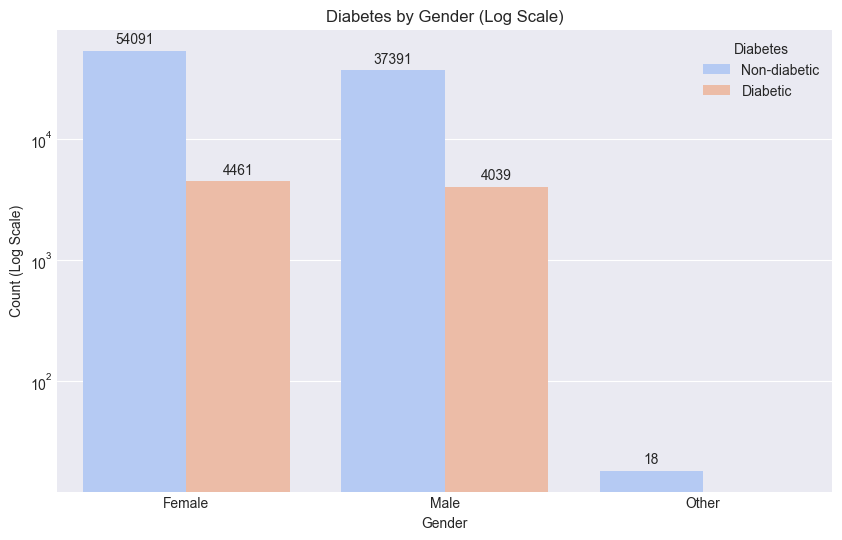

In [14]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=d, x="gender", hue="diabetes", palette="coolwarm")

# log scale so the '18' count is actually visible
ax.set_yscale("log")

# text labels on top of the bars for other's exact counts
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title("Diabetes by Gender (Log Scale)")
plt.xlabel("Gender")
plt.ylabel("Count (Log Scale)")
plt.legend(title="Diabetes", labels=["Non-diabetic", "Diabetic"])

plt.show()

In [15]:
other_d = d[d["gender"] == "Other"]

other_d

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
1611,2019,Other,23.0,Alabama,0,1,0,0,0,0,0,No Info,24.23,6.1,140,0
2550,2019,Other,19.0,Alaska,0,0,1,0,0,0,0,No Info,27.32,5.7,158,0
2787,2019,Other,39.0,Alaska,0,1,0,0,0,0,0,not current,31.24,6.2,85,0
4385,2015,Other,10.0,Arizona,1,0,0,0,0,0,0,not current,14.09,5.0,140,0
5064,2019,Other,10.0,Arizona,0,0,1,0,0,0,0,not current,16.59,6.1,160,0
7975,2019,Other,45.0,Arkansas,0,0,0,1,0,0,0,never,27.32,4.0,159,0
19647,2019,Other,47.0,Florida,0,0,1,0,0,0,0,never,36.76,6.6,90,0
19658,2019,Other,47.0,Florida,1,0,0,0,0,0,0,never,36.76,3.5,200,0
22784,2019,Other,53.0,Guam,0,0,1,0,0,0,0,No Info,27.32,6.6,160,0
32002,2019,Other,18.0,Iowa,0,0,1,0,0,0,0,not current,30.19,6.1,90,0


In [16]:
other_d.index

Index([ 1611,  2550,  2787,  4385,  5064,  7975, 19647, 19658, 22784, 32002,
       52722, 58482, 59534, 64571, 69173, 69763, 70701, 70863],
      dtype='int64')

In [17]:
d.drop(
    index=[
        1611,
        2550,
        2787,
        4385,
        5064,
        7975,
        19647,
        19658,
        22784,
        32002,
        52722,
        58482,
        59534,
        64571,
        69173,
        69763,
        70701,
        70863,
    ],
    inplace=True,
    axis=0,
)

- Removing the other data in the gender column as none of them are diabetic 
- some of them having high blood glucose level and hbA1c level than normal which leads to being diabetic but in the dataset they are not diabetic and Given that the "Other" category has only 18 rows and none of them are diabetic

In [18]:
d.duplicated().value_counts()

False    99968
True        14
Name: count, dtype: int64

In [19]:
# AssertionError:
# d[d[d.duplicated] | d.duplicated ]

In [20]:
d.shape

(99982, 16)

In [21]:
duplicate_rows = d[d.duplicated(keep=False)]
d.drop_duplicates(inplace=True)

In [22]:
d.shape

(99968, 16)

In [23]:
d.columns

Index(['year', 'gender', 'age', 'location', 'race:AfricanAmerican',
       'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other',
       'hypertension', 'heart_disease', 'smoking_history', 'bmi',
       'hbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [24]:
d["location"].unique()

array(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California',
       'Colorado', 'Connecticut', 'Delaware', 'District of Columbia',
       'Florida', 'Georgia', 'Guam', 'Hawaii', 'Idaho', 'Illinois',
       'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine',
       'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
       'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
       'New Hampshire', 'New Jersey', 'New Mexico', 'New York',
       'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon',
       'Pennsylvania', 'Puerto Rico', 'Rhode Island', 'South Carolina',
       'South Dakota', 'Tennessee', 'Texas', 'United States', 'Utah',
       'Vermont', 'Virgin Islands', 'Virginia', 'Washington',
       'West Virginia', 'Wisconsin', 'Wyoming'], dtype=object)

In [25]:
df_race = d[
    [
        "race:AfricanAmerican",
        "race:Asian",
        "race:Caucasian",
        "race:Hispanic",
        "race:Other",
    ]
]

by_race = pd.from_dummies(df_race)

d = d.drop(
    columns=[
        "race:AfricanAmerican",
        "race:Asian",
        "race:Caucasian",
        "race:Hispanic",
        "race:Other",
    ]
)

d.insert(2, "race", by_race)

In [26]:
d

,year,gender,race,age,location,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,race:Other,32.0,Alabama,0,0,never,27.32,5.0,100,0
1,2015,Female,race:Asian,29.0,Alabama,0,0,never,19.95,5.0,90,0
2,2015,Male,race:Other,18.0,Alabama,0,0,never,23.76,4.8,160,0
3,2015,Male,race:Caucasian,41.0,Alabama,0,0,never,27.32,4.0,159,0
4,2016,Female,race:AfricanAmerican,52.0,Alabama,0,0,never,23.75,6.5,90,0
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2018,Female,race:Other,33.0,Wyoming,0,0,never,21.21,6.5,90,0
99996,2016,Female,race:Asian,80.0,Wyoming,0,0,No Info,36.66,5.7,100,0
99997,2018,Male,race:Asian,46.0,Wyoming,0,0,ever,36.12,6.2,158,0
99998,2018,Female,race:AfricanAmerican,51.0,Wyoming,0,0,not current,29.29,6.0,155,0


In [27]:
d["race"] = d["race"].str.replace("race:", "")

In [28]:
d["race"] = d["race"].str.replace("AfricanAmerican", "African-American")

In [29]:
d

,year,gender,race,age,location,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,Other,32.0,Alabama,0,0,never,27.32,5.0,100,0
1,2015,Female,Asian,29.0,Alabama,0,0,never,19.95,5.0,90,0
2,2015,Male,Other,18.0,Alabama,0,0,never,23.76,4.8,160,0
3,2015,Male,Caucasian,41.0,Alabama,0,0,never,27.32,4.0,159,0
4,2016,Female,African-American,52.0,Alabama,0,0,never,23.75,6.5,90,0
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2018,Female,Other,33.0,Wyoming,0,0,never,21.21,6.5,90,0
99996,2016,Female,Asian,80.0,Wyoming,0,0,No Info,36.66,5.7,100,0
99997,2018,Male,Asian,46.0,Wyoming,0,0,ever,36.12,6.2,158,0
99998,2018,Female,African-American,51.0,Wyoming,0,0,not current,29.29,6.0,155,0


In [30]:
race_diabetes = d.groupby(["race", "diabetes"]).size().unstack(fill_value=0)

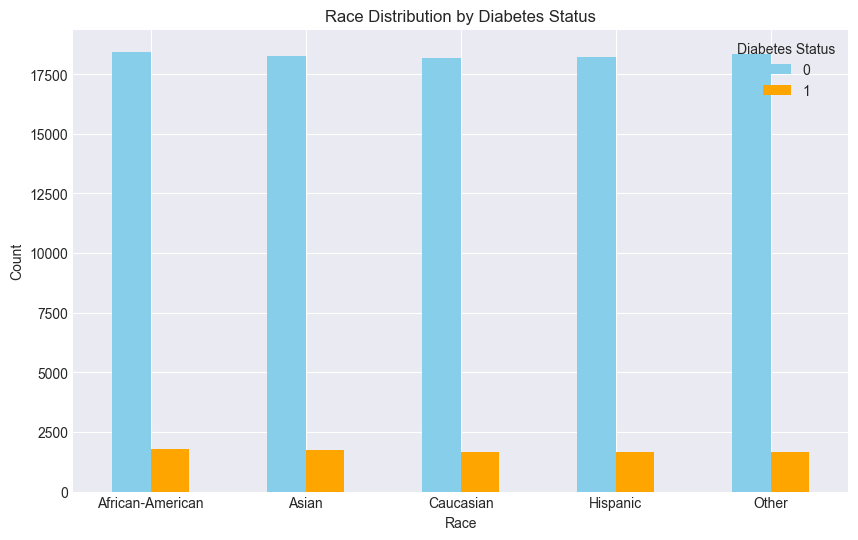

In [31]:
race_diabetes.plot(
    kind="bar", stacked=False, figsize=(10, 6), color=["skyblue", "orange"]
)

plt.title("Race Distribution by Diabetes Status")
plt.xlabel("Race")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Diabetes Status")
plt.show()

- The counts for each racial group (African-American, Asian, Caucasian, Hispanic, and Other) are relatively similar, indicating a balanced across these categories.The data suggests that across all racial categories, there are more individuals without diabetes compared to those with diabetes. However, the differences are not much, indicating that diabetes frequency may be relatively consistent across these racial groups.

In [32]:
d["age"].value_counts().sum

<bound method Series.sum of age
80.00    5619
51.00    1619
47.00    1572
48.00    1568
49.00    1541
         ... 
0.48       83
1.00       83
0.40       66
0.16       59
0.08       36
Name: count, Length: 102, dtype: int64>

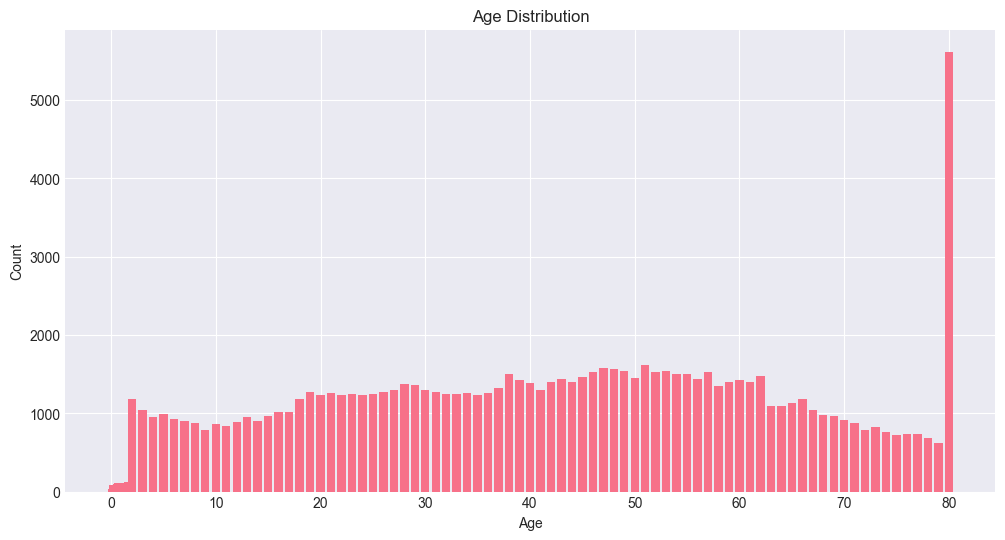

In [33]:
age_counts = d["age"].value_counts().sort_index()
plt.figure(figsize=(12, 6))
plt.bar(x=age_counts.index, height=age_counts.values)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")
plt.show()

In [34]:
d["age"][d["age"] >= 80]

17       80.0
29       80.0
35       80.0
54       80.0
65       80.0
         ... 
99963    80.0
99988    80.0
99989    80.0
99992    80.0
99996    80.0
Name: age, Length: 5619, dtype: float64

In [35]:
bins = [0, 18, 25, 35, 45, 55, 65, np.inf]

age_order = ["0-18", "18-24", "25-34", "35-44", "45-54", "55-64", "65+"]

d.insert(3, "age_cat", pd.cut(d["age"], bins, labels=age_order))

In [36]:
bins = [0, 18.5, 25, 30, 35, 40, np.inf]
bmi_order = [
    "Underweight",
    "Normal weight",
    "Overweight",
    "Obese (Class I)",
    "Obese (Class II)",
    "Obese (Class III)",
]


d.insert(9, "bmi_category", pd.cut(d["bmi"], bins, labels=bmi_order))

In [37]:
d

,year,gender,race,age_cat,age,location,hypertension,heart_disease,smoking_history,bmi_category,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,Other,25-34,32.0,Alabama,0,0,never,Overweight,27.32,5.0,100,0
1,2015,Female,Asian,25-34,29.0,Alabama,0,0,never,Normal weight,19.95,5.0,90,0
2,2015,Male,Other,0-18,18.0,Alabama,0,0,never,Normal weight,23.76,4.8,160,0
3,2015,Male,Caucasian,35-44,41.0,Alabama,0,0,never,Overweight,27.32,4.0,159,0
4,2016,Female,African-American,45-54,52.0,Alabama,0,0,never,Normal weight,23.75,6.5,90,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2018,Female,Other,25-34,33.0,Wyoming,0,0,never,Normal weight,21.21,6.5,90,0
99996,2016,Female,Asian,65+,80.0,Wyoming,0,0,No Info,Obese (Class II),36.66,5.7,100,0
99997,2018,Male,Asian,45-54,46.0,Wyoming,0,0,ever,Obese (Class II),36.12,6.2,158,0
99998,2018,Female,African-American,45-54,51.0,Wyoming,0,0,not current,Overweight,29.29,6.0,155,0


In [38]:
d["smoking_history"].unique()

array(['never', 'not current', 'current', 'No Info', 'ever', 'former'],
      dtype=object)

In [39]:
d["smoking_history"] = d["smoking_history"].str.title()

smoking_mapping = {
    "Never": "Never",
    "Not Current": "Former",
    "Former": "Former",
    "Ever": "Former",
    "Current": "Current",
    "No Info": "Unknown",
}

d["smoking_category"] = d["smoking_history"].map(smoking_mapping)

In [40]:
d

,year,gender,race,age_cat,age,location,hypertension,heart_disease,smoking_history,bmi_category,bmi,hbA1c_level,blood_glucose_level,diabetes,smoking_category
0,2020,Female,Other,25-34,32.0,Alabama,0,0,Never,Overweight,27.32,5.0,100,0,Never
1,2015,Female,Asian,25-34,29.0,Alabama,0,0,Never,Normal weight,19.95,5.0,90,0,Never
2,2015,Male,Other,0-18,18.0,Alabama,0,0,Never,Normal weight,23.76,4.8,160,0,Never
3,2015,Male,Caucasian,35-44,41.0,Alabama,0,0,Never,Overweight,27.32,4.0,159,0,Never
4,2016,Female,African-American,45-54,52.0,Alabama,0,0,Never,Normal weight,23.75,6.5,90,0,Never
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2018,Female,Other,25-34,33.0,Wyoming,0,0,Never,Normal weight,21.21,6.5,90,0,Never
99996,2016,Female,Asian,65+,80.0,Wyoming,0,0,No Info,Obese (Class II),36.66,5.7,100,0,Unknown
99997,2018,Male,Asian,45-54,46.0,Wyoming,0,0,Ever,Obese (Class II),36.12,6.2,158,0,Former
99998,2018,Female,African-American,45-54,51.0,Wyoming,0,0,Not Current,Overweight,29.29,6.0,155,0,Former


In [41]:
categorical_cols = [
    "gender",
    "race",
    "age_cat",
    "location",
    "smoking_history",
    "bmi_category",
]

for col in categorical_cols:
    d[col] = d[col].astype("category")

## Handling Categorical Data for Model Training

If categorical features remain as **strings** before type conversion, model training will fail with errors such as:

- `ValueError: must be non-negative`
- `TypeError: unsupported operand type(s) for -: 'str' and 'int'`

This occurs because **machine learning models expect numerical inputs**, not text.

---

## Solution: Encode Categorical Features

While `.astype("category")` stores strings efficiently with internal codes, scikit-learn models like GaussianNB still require explicit numerical encoding.

### Approach later used: One-Hot Encoding

Use `pd.get_dummies()` to convert categorical columns to binary (0/1) numerical features:

```python
X = pd.get_dummies(X, drop_first=True)
```

This creates separate columns for each category, making the data suitable for numerical models.

### Alternative: Label Encoding

For ordinal categories, use `LabelEncoder` or map to integers, but one-hot is safer for non-ordinal data.

In [42]:
d.head(2)

,year,gender,race,age_cat,age,location,hypertension,heart_disease,smoking_history,bmi_category,bmi,hbA1c_level,blood_glucose_level,diabetes,smoking_category
0,2020,Female,Other,25-34,32.0,Alabama,0,0,Never,Overweight,27.32,5.0,100,0,Never
1,2015,Female,Asian,25-34,29.0,Alabama,0,0,Never,Normal weight,19.95,5.0,90,0,Never


In [43]:
d[d["diabetes"] == 1].value_counts()

year  gender  race              age_cat  age   location        hypertension  heart_disease  smoking_history  bmi_category      bmi    hbA1c_level  blood_glucose_level  diabetes  smoking_category
2015  Female  African-American  25-34    30.0  South Carolina  0             0              Not Current      Obese (Class II)  38.54  6.1          159                  1         Former              1
                                         32.0  Tennessee       0             0              No Info          Overweight        27.57  7.5          200                  1         Unknown             1
                                         35.0  Arizona         0             0              Not Current      Overweight        27.89  6.1          280                  1         Former              1
                                35-44    36.0  New York        0             0              Never            Obese (Class II)  40.00  5.7          260                  1         Never               1
     

In [44]:
d[d["diabetes"] == 0].value_counts()

year  gender  race              age_cat  age    location      hypertension  heart_disease  smoking_history  bmi_category   bmi    hbA1c_level  blood_glucose_level  diabetes  smoking_category
2015  Female  African-American  0-18     0.16   Mississippi   0             0              No Info          Underweight    12.15  6.6          100                  0         Unknown             1
                                         0.24   Iowa          0             0              No Info          Underweight    17.82  6.0          126                  0         Unknown             1
                                         0.32   Illinois      0             0              No Info          Normal weight  21.70  3.5          158                  0         Unknown             1
                                                Pennsylvania  0             0              No Info          Normal weight  18.57  4.0          160                  0         Unknown             1
                         

In [45]:
d.columns

Index(['year', 'gender', 'race', 'age_cat', 'age', 'location', 'hypertension',
       'heart_disease', 'smoking_history', 'bmi_category', 'bmi',
       'hbA1c_level', 'blood_glucose_level', 'diabetes', 'smoking_category'],
      dtype='object')

In [46]:
print(f"Shape: {d.shape}")
print(f"Diabetes Rate %: {d['diabetes'].mean():.1%}")
print("Missing:\n", d.isna().sum())

Shape: (99968, 15)
Diabetes Rate %: 8.5%
Missing:
 year                   0
gender                 0
race                   0
age_cat                0
age                    0
location               0
hypertension           0
heart_disease          0
smoking_history        0
bmi_category           0
bmi                    0
hbA1c_level            0
blood_glucose_level    0
diabetes               0
smoking_category       0
dtype: int64


In [47]:
print(" columns:")
print(d.columns.tolist())
print("\ndtypes:")
print(d.dtypes)

 columns:
['year', 'gender', 'race', 'age_cat', 'age', 'location', 'hypertension', 'heart_disease', 'smoking_history', 'bmi_category', 'bmi', 'hbA1c_level', 'blood_glucose_level', 'diabetes', 'smoking_category']

dtypes:
year                      int64
gender                 category
race                   category
age_cat                category
age                     float64
location               category
hypertension              int64
heart_disease             int64
smoking_history        category
bmi_category           category
bmi                     float64
hbA1c_level             float64
blood_glucose_level       int64
diabetes                  int64
smoking_category         object
dtype: object


In [48]:
sns.set_palette("husl")

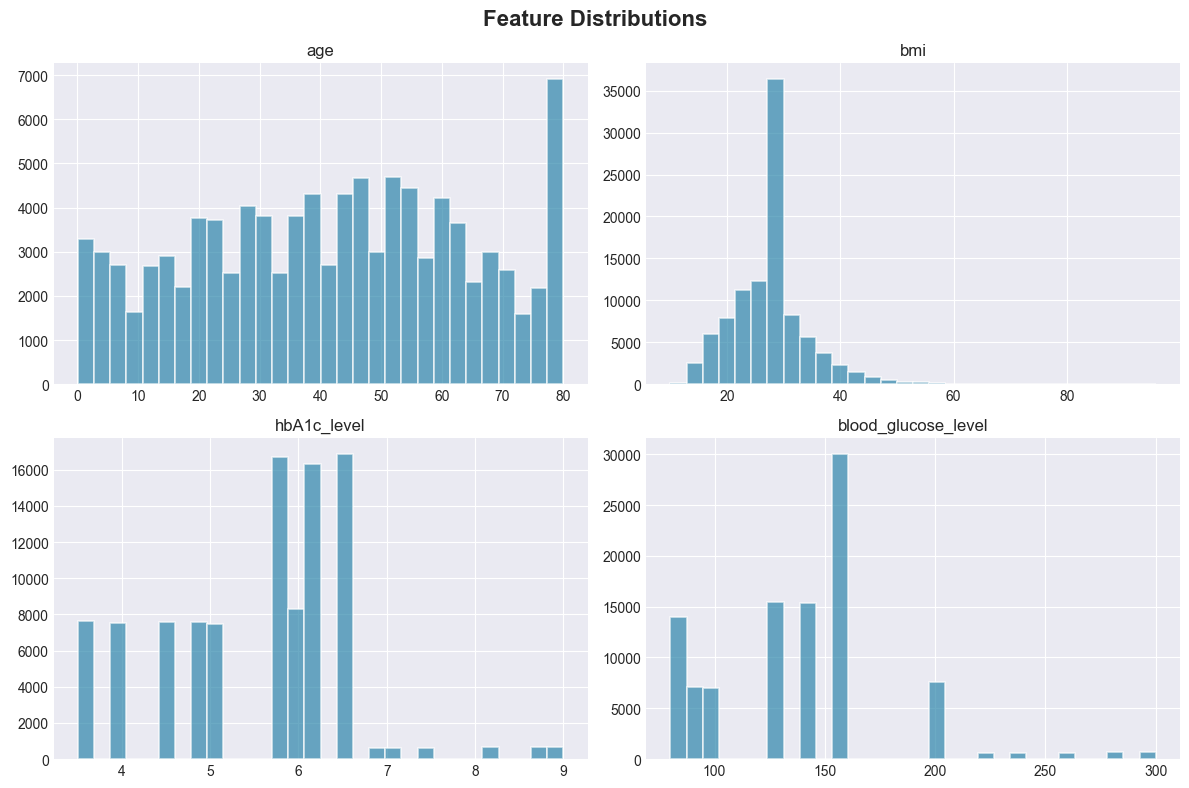

In [49]:
d[["age", "bmi", "hbA1c_level", "blood_glucose_level"]].hist(
    bins=30,
    figsize=(12, 8),
    color="#2E86AB",
    edgecolor="white",
    linewidth=1.2,
    alpha=0.7,
)
plt.suptitle("Feature Distributions", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

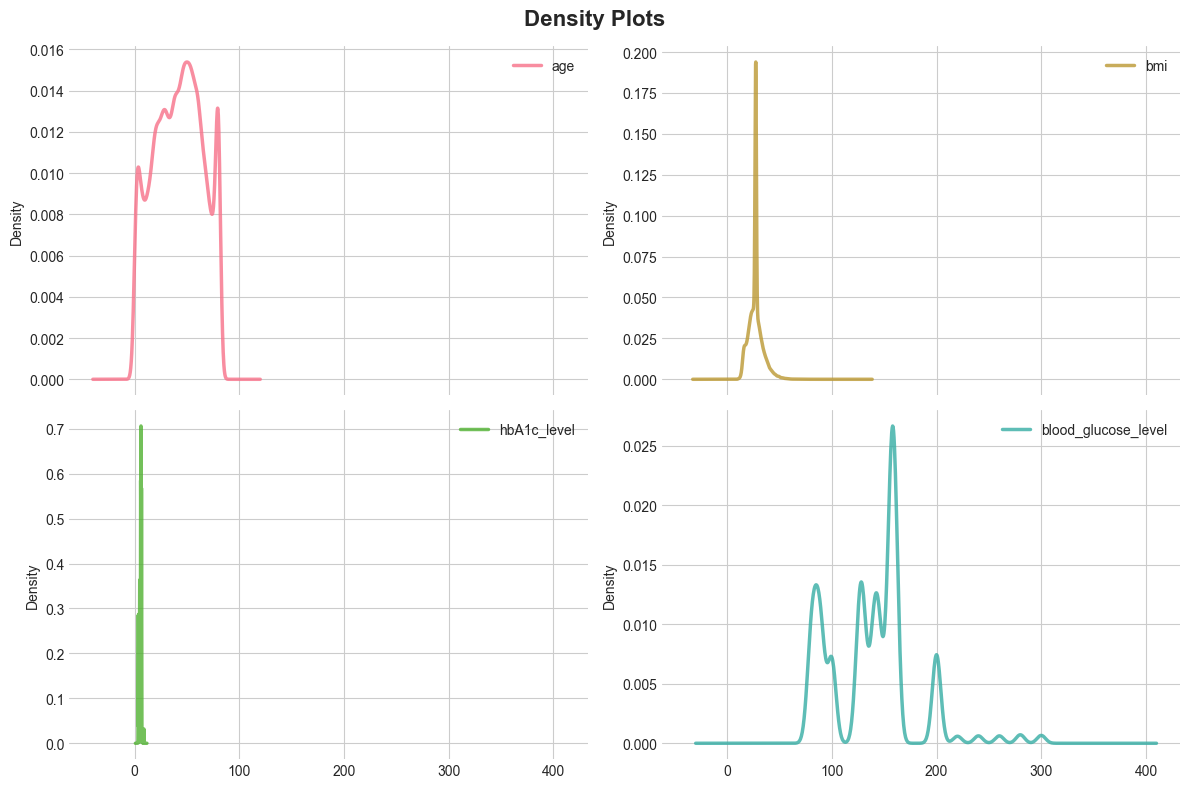

In [50]:
sns.set_style("whitegrid")
fig, axes = d[["age", "bmi", "hbA1c_level", "blood_glucose_level"]].plot(
    kind="density", subplots=True, layout=(2, 2), figsize=(12, 8), lw=2.5, alpha=0.8
)
plt.suptitle("Density Plots", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

- skewness/outliers
- Age: Normal distribution
- BMI: Right-skewed
- HbA1c:
- Blood Glucose: Right-skewed


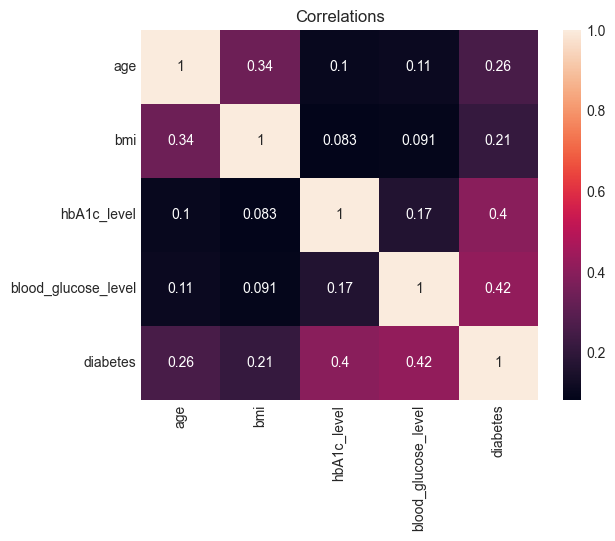

In [51]:
sns.heatmap(
    d[["age", "bmi", "hbA1c_level", "blood_glucose_level", "diabetes"]].corr(),
    annot=True,
)
plt.title("Correlations")
plt.show()

In [52]:
corr = (
    d[
        [
            "age",
            "bmi",
            "hbA1c_level",
            "blood_glucose_level",
            "hypertension",
            "heart_disease",
            "diabetes",
        ]
    ]
    .corr()["diabetes"]
    .sort_values(ascending=False)
)
print("Top correlations with Diabetes:")
print(corr)

Top correlations with Diabetes:
diabetes               1.000000
blood_glucose_level    0.419603
hbA1c_level            0.400724
age                    0.258023
bmi                    0.214378
hypertension           0.197801
heart_disease          0.171711
Name: diabetes, dtype: float64


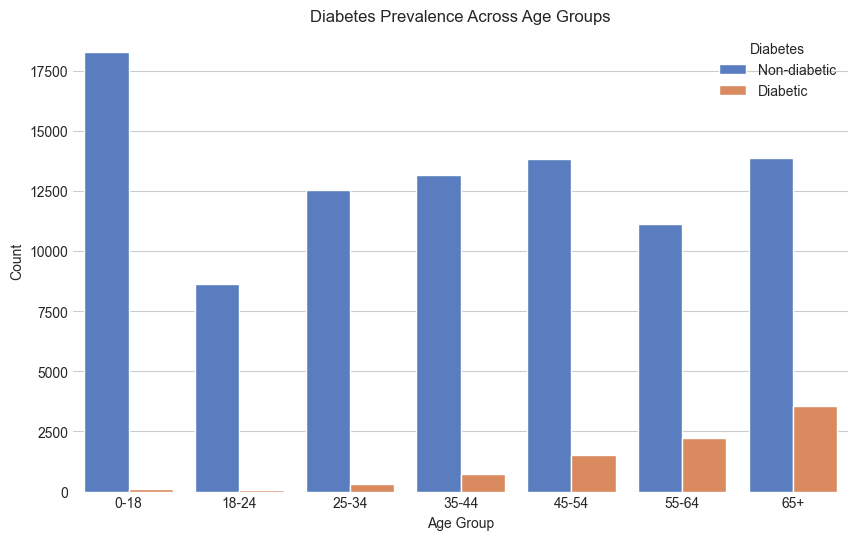

In [53]:
plt.figure(figsize=(10, 6))
sns.countplot(x="age_cat", hue="diabetes", data=d, palette="muted")
plt.title("Diabetes Prevalence Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.legend(title="Diabetes", labels=["Non-diabetic", "Diabetic"])
plt.show()

In [54]:
d.groupby(["age_cat", "diabetes"], observed=True).aggregate({"age_cat": "count"})
# The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

age_cat
age_cat diabetes         
0-18    0           18299
        1              92
18-24   0            8650
        1              78
25-34   0           12543
        1             309
35-44   0           13150
        1             735
45-54   0           13846
        1            1513
55-64   0           11113
        1            2209
65+     0           13867
        1            3564

## Findings: Diabetes by Age Group

- Diabetes is **rare in children and young adults** (0–18 and 18–24).
- The number of people with diabetes **goes up as age increases** starting from the 25–34 group..
- After age 35, diabetes becomes **more common**.
- Older age groups (55–64 and 65+) have the **highest diabetes rates**.
- Fewer people are without diabetes in the **older age groups**.
- Age Pattern Found:


Conclusion: Diabetes increases dramatically with age


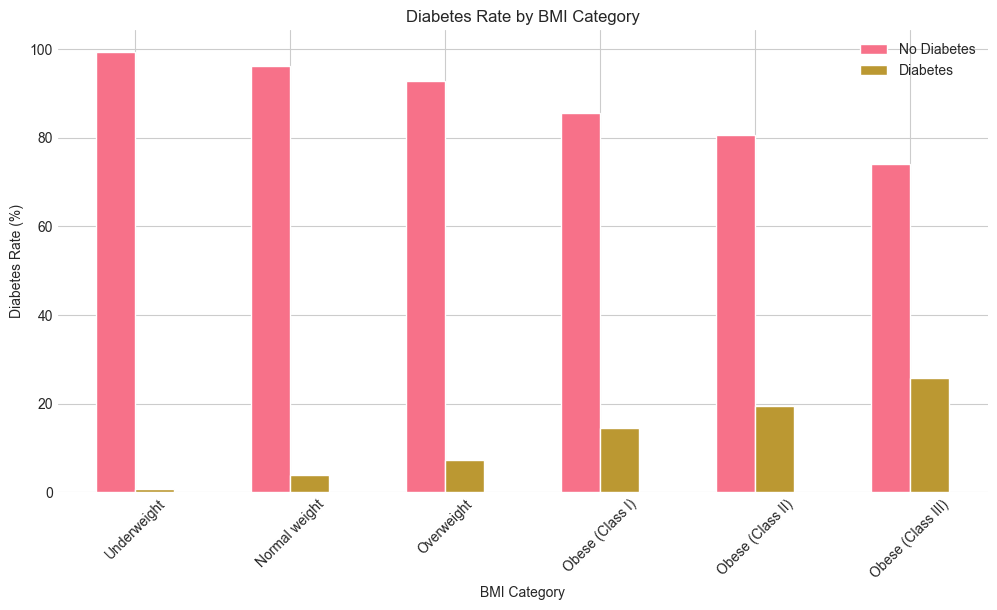

In [55]:
bmi_diabetes = pd.crosstab(d["bmi_category"], d["diabetes"], normalize="index") * 100
bmi_diabetes.plot(kind="bar", figsize=(12, 6))
plt.title("Diabetes Rate by BMI Category")
plt.xlabel("BMI Category")
plt.ylabel("Diabetes Rate (%)")
plt.xticks(rotation=45)
plt.legend(["No Diabetes", "Diabetes"])
plt.show()

## Findings: Diabetes by BMI Category

- People with **lower BMI** (underweight and normal weight) have **very low diabetes rates**.
- Diabetes becomes **more common as BMI increases**.
- Overweight individuals show a **clear increase** in diabetes cases.
- Obese groups have the **highest diabetes rates**.
- The most severe obesity category has the **largest proportion of people with diabetes**.
- Overall, higher BMI is **strongly linked to higher diabetes prevalence**.


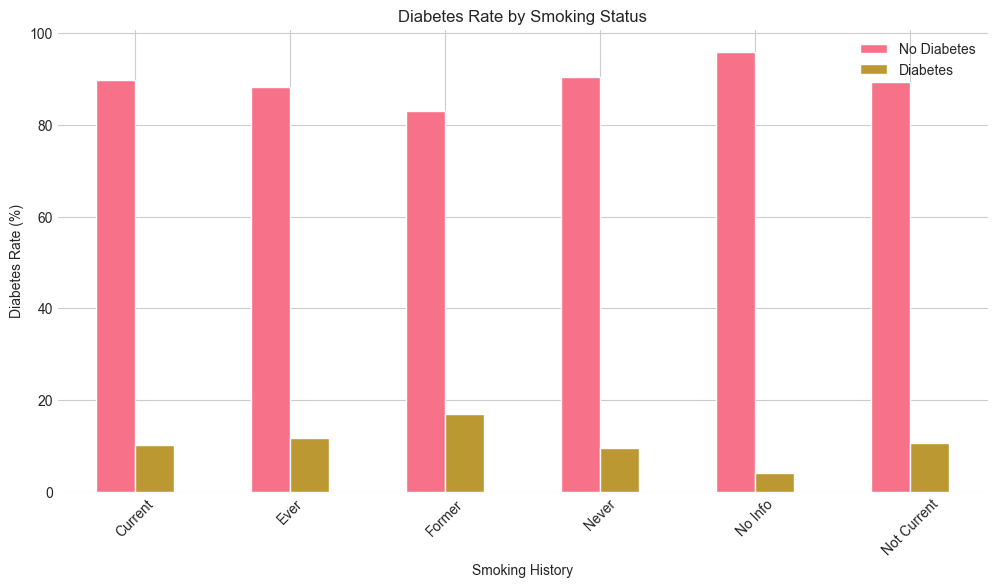

In [56]:
smoking_diabetes = (
    pd.crosstab(d["smoking_history"], d["diabetes"], normalize="index") * 100
)
smoking_diabetes.plot(kind="bar", figsize=(12, 6))
plt.title("Diabetes Rate by Smoking Status")
plt.xlabel("Smoking History")
plt.ylabel("Diabetes Rate (%)")
plt.xticks(rotation=45)
plt.legend(["No Diabetes", "Diabetes"])
plt.show()

## Findings: Diabetes by Smoking Status

- **Former smokers** have the highest diabetes rate.
- **Current smokers** also show a noticeable level of diabetes.
- People who **never smoked** have a lower diabetes rate.
- Those with **no smoking information** show the lowest diabetes rate.
- Overall, people with a **history of smoking** tend to have more diabetes than non-smokers.

In [57]:
d.columns

Index(['year', 'gender', 'race', 'age_cat', 'age', 'location', 'hypertension',
       'heart_disease', 'smoking_history', 'bmi_category', 'bmi',
       'hbA1c_level', 'blood_glucose_level', 'diabetes', 'smoking_category'],
      dtype='object')

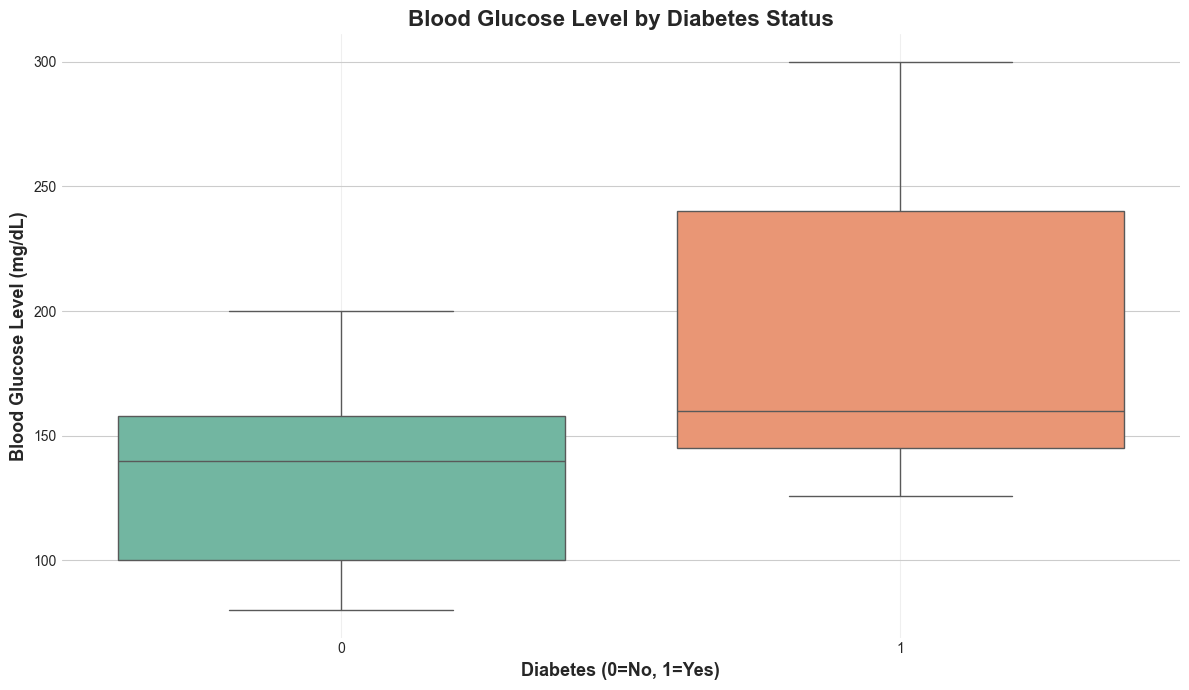

In [58]:
sns.set_style("whitegrid")
plt.figure(figsize=(12, 7))
sns.boxplot(
    data=d,
    x="diabetes",
    y="blood_glucose_level",
    hue="diabetes",
    palette="Set2",
    legend=False,
)
plt.title("Blood Glucose Level by Diabetes Status", fontsize=16, fontweight="bold")
plt.xlabel("Diabetes (0=No, 1=Yes)", fontsize=13, fontweight="bold")
plt.ylabel("Blood Glucose Level (mg/dL)", fontsize=13, fontweight="bold")
plt.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

## Findings: Blood Glucose Level by Diabetes Status

- People **with diabetes** have **higher blood glucose levels**.
- People **without diabetes** have **lower and more stable** glucose levels.
- The glucose levels for people with diabetes show **more variation**.
- There is a **clear difference** in blood glucose levels between diabetic and non-diabetic groups.


In [59]:
d["diabetes"].value_counts()
print(f"No Diabetes: {(d['diabetes']==0).sum()}")
print(f"With Diabetes: {(d['diabetes']==1).sum()}")

No Diabetes: 91468
With Diabetes: 8500


Data is VERY imbalanced!

91.5% have no diabetes

8.5% have diabetes

<Figure size 1200x600 with 0 Axes>

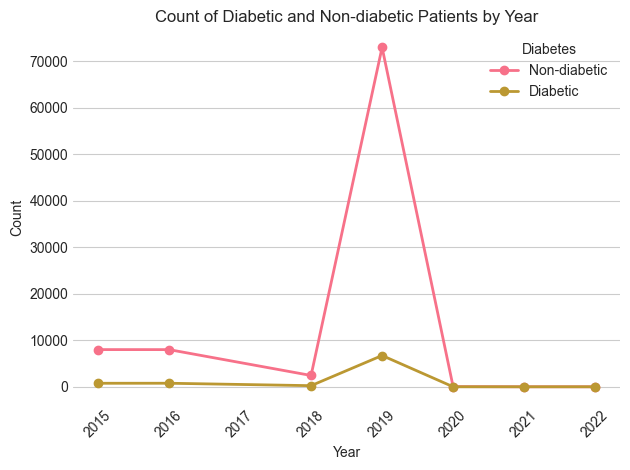

In [60]:
yearly_diabetes = d.groupby(["year", "diabetes"]).size().unstack(fill_value=0)
plt.figure(figsize=(12, 6))
yearly_diabetes.plot(kind="line", marker="o", linewidth=2)
plt.title("Count of Diabetic and Non-diabetic Patients by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Diabetes", labels=["Non-diabetic", "Diabetic"])
plt.grid(axis="x")
plt.tight_layout()
plt.show()

In [61]:
yearly_diabetes = d.groupby(["year", "diabetes"]).size().unstack(fill_value=0)
print("\nYearly Diabetes Distribution:")
print(yearly_diabetes)


Yearly Diabetes Distribution:
diabetes      0     1
year                 
2015       8000   759
2016       7995   765
2018       2435   243
2019      72987  6727
2020         39     3
2021          6     1
2022          6     2


## Findings: Patient Counts by Year

- The number of patients is **much higher in 2019** than in any other year.
- **Non-diabetic patients** are more common than diabetic patients every year.
- Both diabetic and non-diabetic counts **peak in 2019**.
- After 2019, the number of records **drops sharply**.
- The data is **not evenly distributed across years**.


In [62]:
Q1_bmi = d["bmi"].quantile(0.25)
Q3_bmi = d["bmi"].quantile(0.75)
IQR_bmi = Q3_bmi - Q1_bmi
lower_bmi = Q1_bmi - 1.5 * IQR_bmi
upper_bmi = Q3_bmi + 1.5 * IQR_bmi

print(f"Q1: {Q1_bmi:.2f}")
print(f"Q3: {Q3_bmi:.2f}")
print(f"IQR: {IQR_bmi:.2f}")
print(f"Lower bound: {lower_bmi:.2f}")
print(f"Upper bound: {upper_bmi:.2f}")
print(f"Outliers count: {((d['bmi'] < lower_bmi) | (d['bmi'] > upper_bmi)).sum()}")
print(
    f"Outliers %: {((d['bmi'] < lower_bmi) | (d['bmi'] > upper_bmi)).sum() / len(d) * 100:.2f}%"
)

Q1: 23.63
Q3: 29.58
IQR: 5.95
Lower bound: 14.71
Upper bound: 38.50
Outliers count: 7085
Outliers %: 7.09%


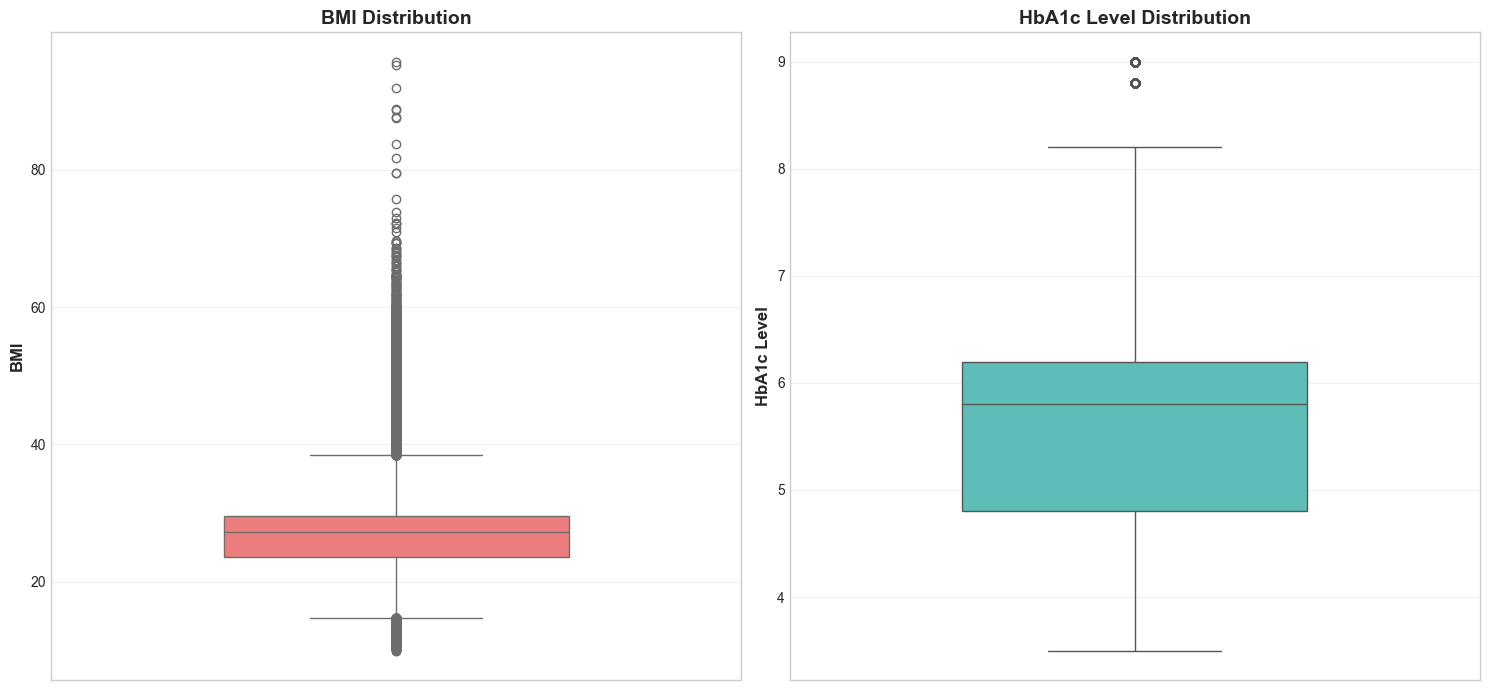

In [63]:
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# BMI
sns.boxplot(y=d["bmi"], ax=axes[0], color="#FF6B6B", width=0.5)
axes[0].set_title("BMI Distribution", fontsize=14, fontweight="bold")
axes[0].set_ylabel("BMI", fontsize=12, fontweight="bold")
axes[0].grid(True, alpha=0.3, axis="y")

# HbA1c
sns.boxplot(y=d["hbA1c_level"], ax=axes[1], color="#4ECDC4", width=0.5)
axes[1].set_title("HbA1c Level Distribution", fontsize=14, fontweight="bold")
axes[1].set_ylabel("HbA1c Level", fontsize=12, fontweight="bold")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

In [64]:
d[(d["bmi"] < lower_bmi) | (d["bmi"] > upper_bmi)]

,year,gender,race,age_cat,age,location,hypertension,heart_disease,smoking_history,bmi_category,bmi,hbA1c_level,blood_glucose_level,diabetes,smoking_category
14,2016,Female,Other,55-64,64.0,Alabama,0,0,Ever,Obese (Class III),49.27,8.2,140,1,Former
50,2016,Female,Other,45-54,54.0,Alabama,0,0,Former,Obese (Class III),44.10,7.0,159,1,Former
53,2016,Male,Caucasian,35-44,43.0,Alabama,0,0,No Info,Obese (Class III),40.17,5.8,90,0,Unknown
62,2015,Male,Hispanic,18-24,24.0,Alabama,0,0,No Info,Obese (Class II),39.93,4.8,145,0,Unknown
67,2015,Female,Asian,35-44,42.0,Alabama,0,0,Never,Obese (Class III),48.06,5.0,159,0,Never
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99952,2016,Female,Caucasian,55-64,56.0,Wyoming,0,0,Never,Obese (Class III),45.52,6.6,159,1,Never
99969,2016,Male,Hispanic,0-18,11.0,Wyoming,0,0,No Info,Underweight,13.90,5.7,140,0,Unknown
99970,2016,Female,Other,55-64,58.0,Wyoming,0,0,Former,Obese (Class III),50.31,5.0,158,0,Former
99983,2016,Male,Hispanic,0-18,5.0,Wyoming,0,0,No Info,Underweight,14.55,6.6,159,0,Unknown


In [65]:
print("BMI Statistics:")
print(f"Min: {d['bmi'].min()}")
print(f"Max: {d['bmi'].max()}")
print(f"Mean: {d['bmi'].mean():.2f}")
print(f"Median: {d['bmi'].median():.2f}")

Q1 = d["bmi"].quantile(0.25)
Q3 = d["bmi"].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR

BMI Statistics:
Min: 10.01
Max: 95.69
Mean: 27.32
Median: 27.32


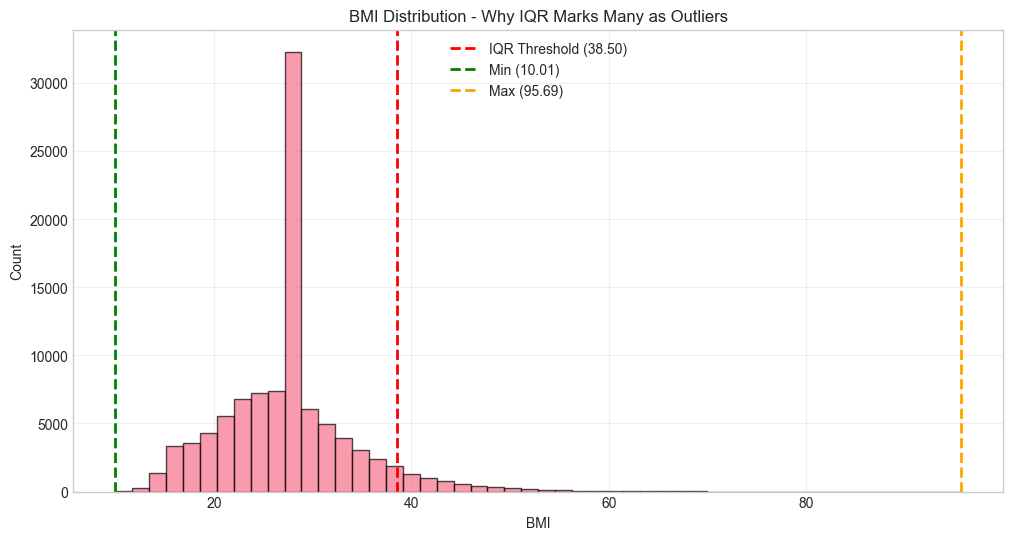

In [66]:
plt.figure(figsize=(12, 6))
d["bmi"].hist(bins=50, edgecolor="black", alpha=0.7)
plt.axvline(
    38.50, color="red", linestyle="--", linewidth=2, label="IQR Threshold (38.50)"
)
plt.axvline(
    d["bmi"].min(),
    color="green",
    linestyle="--",
    linewidth=2,
    label=f'Min ({d["bmi"].min():.2f})',
)
plt.axvline(
    d["bmi"].max(),
    color="orange",
    linestyle="--",
    linewidth=2,
    label=f'Max ({d["bmi"].max():.2f})',
)
plt.title("BMI Distribution - Why IQR Marks Many as Outliers")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [67]:
d.columns = d.columns.str.lower()
print("Standardized columns:", d.columns.tolist())

d_with_outliers = d.copy()
d_clean = d[(d["bmi"] >= 14.71) & (d["bmi"] <= 38.50)].copy()

print(f"\nd_with_outliers: {len(d_with_outliers):,} rows")
print(f"d_clean: {len(d_clean):,} rows")
print(f"diabetes' in columns? {'diabetes' in d_with_outliers.columns}")

Standardized columns: ['year', 'gender', 'race', 'age_cat', 'age', 'location', 'hypertension', 'heart_disease', 'smoking_history', 'bmi_category', 'bmi', 'hba1c_level', 'blood_glucose_level', 'diabetes', 'smoking_category']

d_with_outliers: 99,968 rows
d_clean: 92,883 rows
diabetes' in columns? True


In [68]:
print("d_with_outliers dtypes:")
print(d_with_outliers.dtypes)
print("\nSample of d_with_outliers:")
print(d_with_outliers.head(2))

# Test encoding
X_test = d_with_outliers.drop("diabetes", axis=1)
X_encoded = pd.get_dummies(X_test, drop_first=True)
print("\nAfter get_dummies dtypes:")
print(X_encoded.dtypes)
print("\nShape before:", X_test.shape, "after:", X_encoded.shape)

d_with_outliers dtypes:
year                      int64
gender                 category
race                   category
age_cat                category
age                     float64
location               category
hypertension              int64
heart_disease             int64
smoking_history        category
bmi_category           category
bmi                     float64
hba1c_level             float64
blood_glucose_level       int64
diabetes                  int64
smoking_category         object
dtype: object

Sample of d_with_outliers:
   year  gender   race age_cat   age location  hypertension  heart_disease  \
0  2020  Female  Other   25-34  32.0  Alabama             0              0   
1  2015  Female  Asian   25-34  29.0  Alabama             0              0   

  smoking_history   bmi_category    bmi  hba1c_level  blood_glucose_level  \
0           Never     Overweight  27.32          5.0                  100   
1           Never  Normal weight  19.95          5.0             

In [69]:
def prepare_smote(X_train_orig, y_train_orig, random_state=42):
    smote = SMOTE(random_state=random_state)
    X_train_smote, y_train_smote = smote.fit_resample(X_train_orig, y_train_orig)
    print(f"Before: {len(X_train_orig)} | After: {len(X_train_smote)}")
    return X_train_smote, y_train_smote

In [70]:
def model_train(X_train, X_test, y_train, y_test, model, m_name, use_smote=False):

    if use_smote:
        X_train_final, y_train_final = prepare_smote(X_train, y_train)
        dataset_name = "WITH SMOTE"
    else:
        X_train_final, y_train_final = X_train, y_train
        dataset_name = "NO SMOTE"

    model.fit(X_train_final, y_train_final)
    y_pred = model.predict(X_test)

    return {
        "Model": m_name,
        "Dataset": dataset_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
    }

In [71]:
models = {
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=10),
    "Random Forest": RandomForestClassifier(
        n_estimators=50, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=50, random_state=42),
}

In [72]:
d_with_outliers.columns

Index(['year', 'gender', 'race', 'age_cat', 'age', 'location', 'hypertension',
       'heart_disease', 'smoking_history', 'bmi_category', 'bmi',
       'hba1c_level', 'blood_glucose_level', 'diabetes', 'smoking_category'],
      dtype='object')

In [73]:
X = d_with_outliers.drop(["diabetes", "location", "year"], axis=1)
y = d_with_outliers["diabetes"]
X = pd.get_dummies(X, drop_first=True)
X_train_orig, X_test, y_train_orig, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Align X_test columns with X_train_orig
X_test = X_test.reindex(columns=X_train_orig.columns, fill_value=0)

X_train_smote, y_train_smote = prepare_smote(X_train_orig, y_train_orig)

results = []

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")

    # WITHOUT SMOTE
    result_no_smote = model_train(
        X_train_orig, X_test, y_train_orig, y_test, model, model_name, use_smote=False
    )
    results.append(result_no_smote)

    # WITH SMOTE
    result_with_smote = model_train(
        X_train_orig, X_test, y_train_orig, y_test, model, model_name, use_smote=True
    )
    results.append(result_with_smote)

# ===RESULTS TABLE ===
df_results = pd.DataFrame(results)
print("\n" + "=" * 100)
print("MODEL COMPARISON: WITH vs WITHOUT SMOTE")
print("=" * 100)
print(df_results.to_string(index=False))

Before: 79974 | After: 146348

Training Naive Bayes...
Before: 79974 | After: 146348

Training Decision Tree...
Before: 79974 | After: 146348

Training Random Forest...
Before: 79974 | After: 146348

Training Gradient Boosting...
Before: 79974 | After: 146348

Training XGBoost...
Before: 79974 | After: 146348

MODEL COMPARISON: WITH vs WITHOUT SMOTE
            Model    Dataset  Accuracy  Precision   Recall  F1-Score
      Naive Bayes   NO SMOTE  0.832300   0.308548 0.783529  0.442746
      Naive Bayes WITH SMOTE  0.780634   0.258973 0.848824  0.396865
    Decision Tree   NO SMOTE  0.971842   0.979747 0.682941  0.804853
    Decision Tree WITH SMOTE  0.926978   0.548115 0.804118  0.651884
    Random Forest   NO SMOTE  0.970791   0.956628 0.687647  0.800137
    Random Forest WITH SMOTE  0.961488   0.803525 0.724118  0.761757
Gradient Boosting   NO SMOTE  0.972292   1.000000 0.674118  0.805341
Gradient Boosting WITH SMOTE  0.933980   0.579365 0.815882  0.677577
          XGBoost   NO SMOT

In [74]:
X.columns

Index(['age', 'hypertension', 'heart_disease', 'bmi', 'hba1c_level',
       'blood_glucose_level', 'gender_Male', 'race_Asian', 'race_Caucasian',
       'race_Hispanic', 'race_Other', 'age_cat_18-24', 'age_cat_25-34',
       'age_cat_35-44', 'age_cat_45-54', 'age_cat_55-64', 'age_cat_65+',
       'smoking_history_Ever', 'smoking_history_Former',
       'smoking_history_Never', 'smoking_history_No Info',
       'smoking_history_Not Current', 'bmi_category_Normal weight',
       'bmi_category_Overweight', 'bmi_category_Obese (Class I)',
       'bmi_category_Obese (Class II)', 'bmi_category_Obese (Class III)',
       'smoking_category_Former', 'smoking_category_Never',
       'smoking_category_Unknown'],
      dtype='object')

In [75]:
# plt.figure(figsize=(10, 5))
# plt.bar(df_results['Model'], df_results['Accuracy'])
# plt.title('Accuracy Comparison')
# plt.ylabel('Accuracy')
# plt.xlabel('Model')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

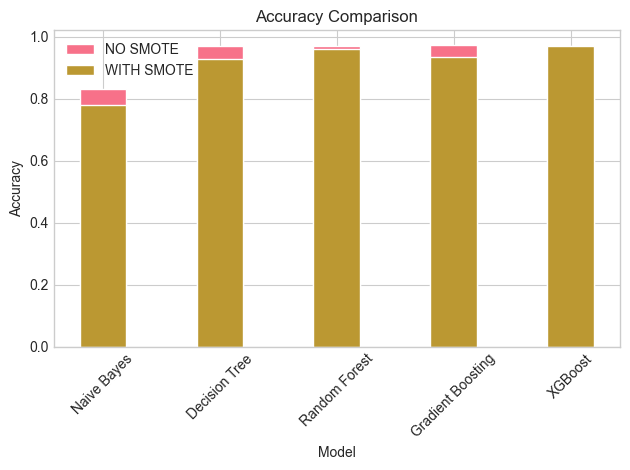

In [76]:
models = df_results["Model"].unique()
no_smote = df_results[df_results["Dataset"] == "NO SMOTE"]["Accuracy"].values
with_smote = df_results[df_results["Dataset"] == "WITH SMOTE"]["Accuracy"].values

plt.bar(models, no_smote, width=0.4, label="NO SMOTE")
plt.bar(models, with_smote, width=0.4, label="WITH SMOTE")

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

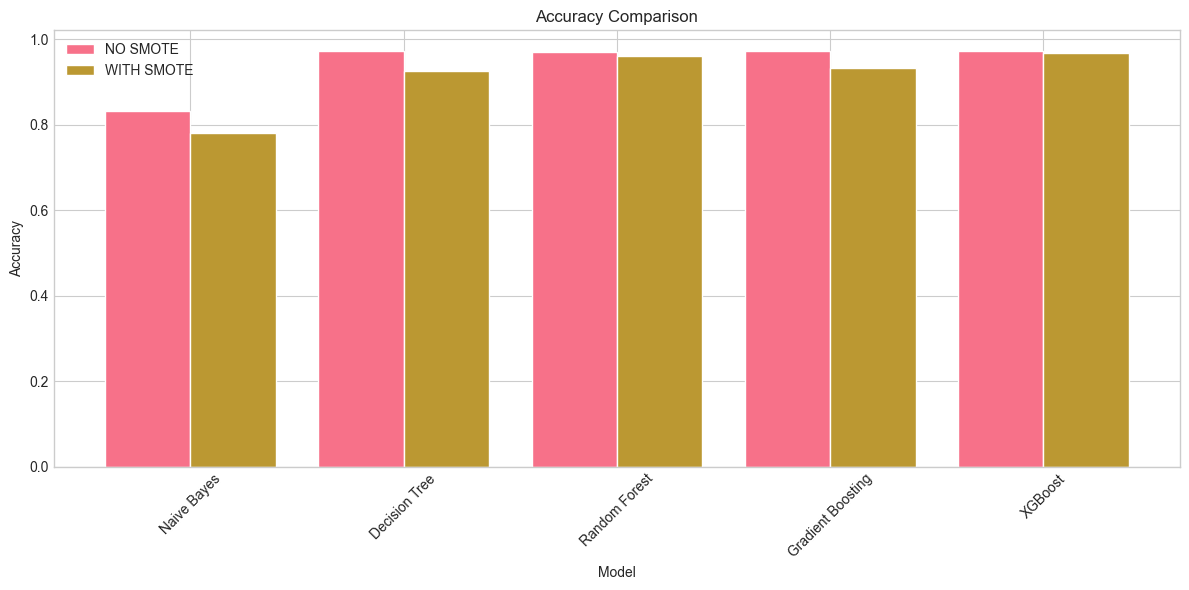

In [77]:
plt.figure(figsize=(12, 6))
models_plot = df_results["Model"].unique()
no_smote = df_results[df_results["Dataset"] == "NO SMOTE"]["Accuracy"].values
with_smote = df_results[df_results["Dataset"] == "WITH SMOTE"]["Accuracy"].values

x = range(len(models))
plt.bar([i - 0.2 for i in x], no_smote, width=0.4, label="NO SMOTE")
plt.bar([i + 0.2 for i in x], with_smote, width=0.4, label="WITH SMOTE")

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.xticks(x, models, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

- Basically with this i - 0.2 for i in x - Subtracts 0.2 from every number in x 
- So that the bar position will shift to left (for "NO SMOTE")
    - i - 0.2 = left
    - i + 0.2 = right

In [85]:
models = {
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=10),
    "Random Forest": RandomForestClassifier(
        n_estimators=50, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50, random_state=42),
    "XGBoost": xgb.XGBClassifier(n_estimators=50, random_state=42),
}

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    print(f"{model_name}:")
    print(f"  Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"  Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"  F1-Score: {f1_score(y_test, y_pred):.4f}")
    print(f"  Confusion Matrix:\n{cm}")
    print("-" * 50)


Training Naive Bayes...
Naive Bayes:
  Accuracy: 0.7806
  Precision: 0.2590
  Recall: 0.8488
  F1-Score: 0.3969
  Confusion Matrix:
[[14165  4129]
 [  257  1443]]
--------------------------------------------------

Training Decision Tree...
Decision Tree:
  Accuracy: 0.9270
  Precision: 0.5481
  Recall: 0.8041
  F1-Score: 0.6519
  Confusion Matrix:
[[17167  1127]
 [  333  1367]]
--------------------------------------------------

Training Random Forest...
Random Forest:
  Accuracy: 0.9615
  Precision: 0.8035
  Recall: 0.7241
  F1-Score: 0.7618
  Confusion Matrix:
[[17993   301]
 [  469  1231]]
--------------------------------------------------

Training Gradient Boosting...
Gradient Boosting:
  Accuracy: 0.9340
  Precision: 0.5794
  Recall: 0.8159
  F1-Score: 0.6776
  Confusion Matrix:
[[17287  1007]
 [  313  1387]]
--------------------------------------------------

Training XGBoost...
XGBoost:
  Accuracy: 0.9690
  Precision: 0.9098
  Recall: 0.7059
  F1-Score: 0.7950
  Confusion Mat

In [86]:
bayes_model = models["Naive Bayes"]
bayes_model.fit(X_train_smote, y_train_smote)
y_pred_bayes = bayes_model.predict(X_test)

cm_bayes = confusion_matrix(y_test, y_pred_bayes)
print(f"Confusion Matrix:\n{cm_bayes}")

Confusion Matrix:
[[14165  4129]
 [  257  1443]]


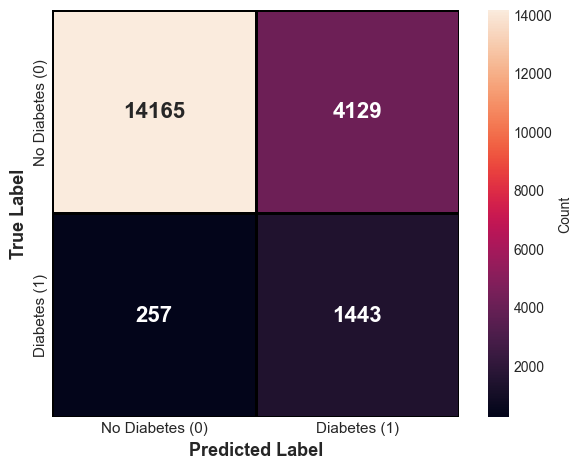

In [87]:
plt.Figure(figsize=(10, 8))
sns.heatmap(
    cm_bayes,
    annot=True,
    fmt="d",
    square=True,
    linewidths=2,
    linecolor="black",
    cbar_kws={"label": "Count"},
    annot_kws={"size": 16, "weight": "bold"},
)
plt.xlabel("Predicted Label", fontsize=13, fontweight="bold")
plt.ylabel("True Label", fontsize=13, fontweight="bold")

plt.xticks([0.5, 1.5], ["No Diabetes (0)", "Diabetes (1)"], fontsize=11)
plt.yticks([0.5, 1.5], ["No Diabetes (0)", "Diabetes (1)"], fontsize=11)
plt.tight_layout()

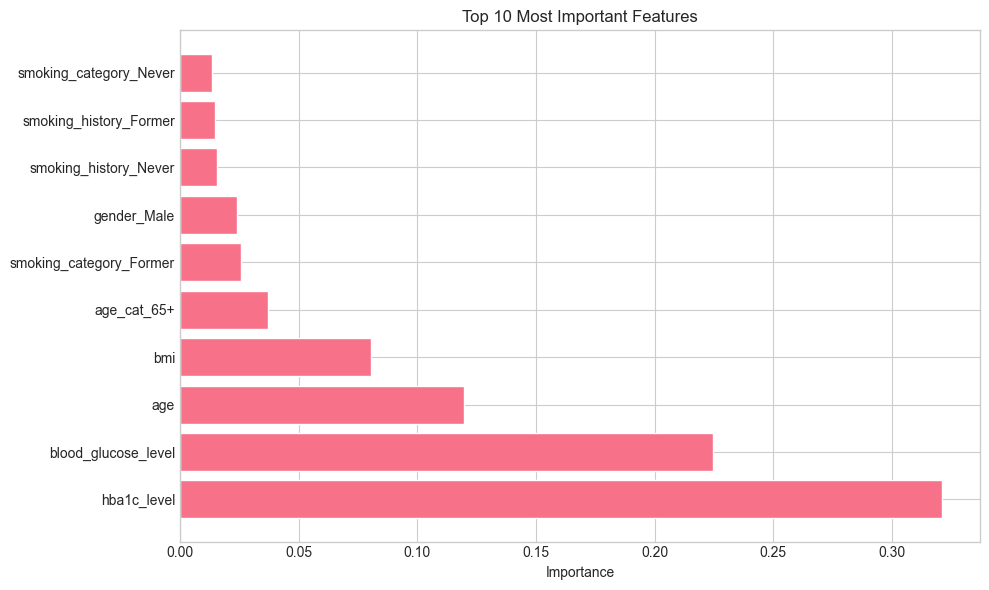

In [88]:
rf_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_model.fit(X_train_smote, y_train_smote)

feature_importance = (
    pd.DataFrame(
        {"Feature": X_train_orig.columns, "Importance": rf_model.feature_importances_}
    )
    .sort_values("Importance", ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.xlabel("Importance")
plt.title("Top 10 Most Important Features")
plt.tight_layout()
plt.show()

## Issues Faced & Solutions

### Issue 1: Class Imbalance (91.5% vs 8.5%)

#### Problem
- Dataset heavily skewed toward the **non-diabetic** class  
- Models achieved **91%+ accuracy** by predicting *“No Diabetes”* for all samples  
- Poor identification of actual diabetic patients  
- Critical limitation for **medical applications**, where false negatives are costly  

#### Solution
- Implemented **SMOTE (Synthetic Minority Over-sampling Technique)**  
- Applied only to the **training dataset** to prevent data leakage  

#### Impact
- Training samples increased from **79,974 → 146,348**  
- Class distribution balanced to **50% diabetic / 50% non-diabetic**  
- **Recall improved** from approximately **60% to 80%+** across models  


### Issue 2: Categorical Data Cannot Train Models

#### Problem
- Features such as **Gender**, **Race**, and **Smoking History** are stored as text strings  
- Scikit-learn models require **numerical inputs** (e.g., 0s and 1s)  
- Training fails with errors such as:  
  - `ValueError: must be non-negative`

#### Solution
- Applied **One-Hot Encoding** using `pd.get_dummies()`  
- Converted categorical features into binary indicator columns  

#### Example
```text
Gender: [Male, Female]
        ↓
Encoded: [Male_0/1, Female_0/1]


### Issue 3: Duplicate Rows in Results Table

#### Problem
- Training loop ran **twice** without separation  
- Results were appended to the **same list**  
- Output showed **10 rows instead of 5** (duplicate entries)

#### Solution
- Separated **regular training** and **SMOTE training**  
- Used a **function-based approach** with a `use_smote` parameter  
- Ensured each model’s result is appended **only once per approach**



```python
results = []
for model in models:
    results.append(...)

for model in models:
    results.append(...)

### Issue 4: SMOTE Output Size Unexpectedly Large

#### Problem
- Expected approximately **100,000 samples** after applying SMOTE  
- Observed **146,348 samples** instead  

#### Solution
- Identified SMOTE’s default behavior: `sampling_strategy='auto'`  
- This setting generates a **50/50 class balance** between minority and majority classes  

## Complete Comparison Table

| Model              | Accuracy | Precision | Recall | F1-Score | TP   | TN    | FP   | FN  | Missed |
|--------------------|----------|-----------|--------|----------|------|-------|------|-----|--------|
| Naive Bayes        | 78.06%   | 25.90%    | 84.88% | 39.69%   | 1443 | 14165 | 4129 | 257 | 257    |
| Decision Tree      | 92.70%   | 54.81%    | 80.41% | 65.19%   | 1367 | 17167 | 1127 | 333 | 333    |
| Random Forest      | 96.15%   | 80.35%    | 72.41% | 76.18%   | 1231 | 17993 | 301  | 469 | 469    |
| Gradient Boosting  | 93.40%   | 57.94%    | 81.59% | 67.76%   | 1387 | 17287 | 1007 | 313 | 313    |
| XGBoost            | 96.90%   | 90.98%    | 70.59% | 79.50%   | 1200 | 18175 | 119  | 500 | 500    |


In [89]:
xgb_model = models["XGBoost"]
xgb_model.fit(X_train_smote, y_train_smote)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"\nXGBoost ROC-AUC Score: {auc_score:.4f}")


XGBoost ROC-AUC Score: 0.9753


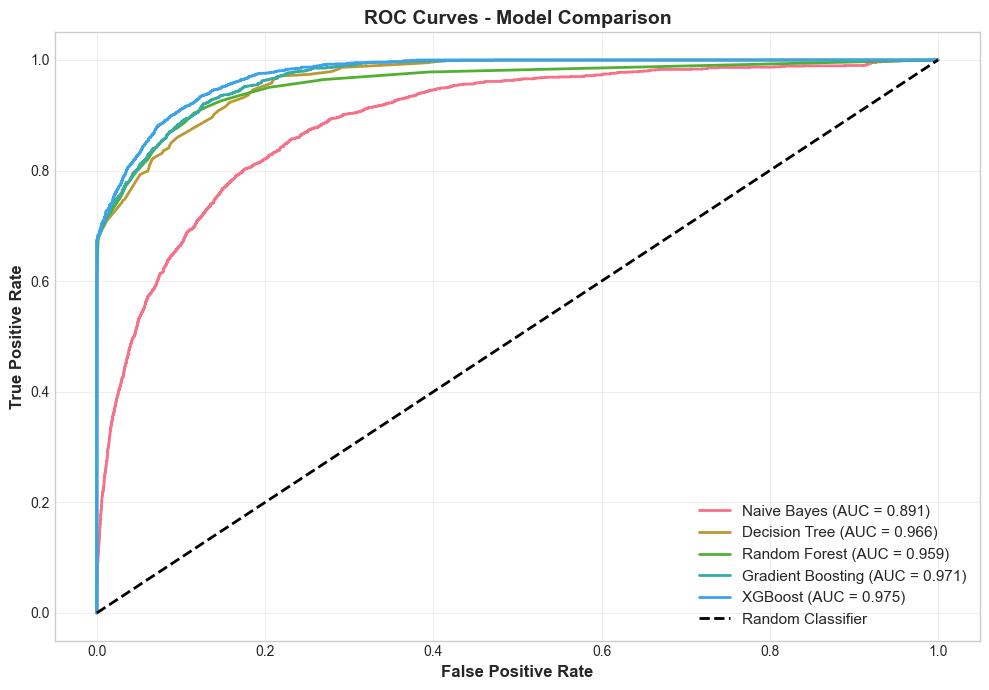

In [90]:
plt.figure(figsize=(10, 7))

for model_name, model in list(models.items())[:5]:
    model.fit(X_train_smote, y_train_smote)
    y_proba = model.predict_proba(X_test)[:, 1]

    fpr, tpr, thresholds = roc_curve(y_test, y_proba)
    auc_val = auc(fpr, tpr)

    plt.plot(fpr, tpr, linewidth=2, label=f"{model_name} (AUC = {auc_val:.3f})")

plt.plot([0, 1], [0, 1], "k--", linewidth=2, label="Random Classifier")
plt.xlabel("False Positive Rate", fontsize=12, fontweight="bold")
plt.ylabel("True Positive Rate", fontsize=12, fontweight="bold")
plt.title("ROC Curves - Model Comparison", fontsize=14, fontweight="bold")
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()